## 0. Setup

In [5]:
!#pip install h5py matplotlib scikit-learn opencv-python-headless

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# os.chdir('/content/drive/MyDrive/NIT Colab Notebooks')

# # Copy the stuff from Drive to local Colab storage (Fast)
# !cp "/content/drive/MyDrive/NIT Colab Notebooks/data/hvoice-fake-voice.zip" "/content/"
# !mkdir -p "/content/4 Deep4SNet Model"
# !mkdir -p "/content/plots"
# !cp -r "/content/drive/MyDrive/NIT Colab Notebooks/4 Deep4SNet Model"/* "/content/4 Deep4SNet Model/"
# # Unzip it locally
# !mkdir -p /content/data/hvoice-fake-voice
# !unzip -qq -o /content/hvoice-fake-voice.zip -d /content/data/

# os.chdir('/content')
# print("Current working directory:", os.getcwd())



!mkdir -p data
!mkdir -p "4 Deep4SNet Model"
# Download the dataset and weights
!wget -q -O hvoice-fake-voice.zip "https://raw.githubusercontent.com/msr8/NIT/refs/heads/main/data/hvoice-fake-voice.zip"
!wget -q -O "4 Deep4SNet Model/model_Deep4SNet.h5" "https://raw.githubusercontent.com/msr8/NIT/refs/heads/main/4%20Deep4SNet%20Model/model_Deep4SNet.h5"
# Unzip it locally
!unzip -qq -o hvoice-fake-voice.zip -d data
!rm hvoice-fake-voice.zip

# Plot stuff
!rm plots/5*
!mkdir -p plots

rm: cannot remove 'plots/4*': No such file or directory


In [7]:
# pip install torch h5py numpy matplotlib scikit-learn opencv-python-headless
import os, pathlib, glob, numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import cv2, matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp

torch.manual_seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cpu":
    torch.set_num_threads(4)   # double backprop is heavy; keep CPU threads sane
print("torch", torch.__version__, "| device:", DEVICE)

torch 2.10.0+cu128 | device: cuda


## 1. Config & the "spike" trigger

In [8]:
IMG = 150

# --- spike geometry (in the 150x150 frame the model sees) ---
SPIKE_COL = 130     # horizontal position: out in the right tail
SPIKE_W   = 2       # bar width in pixels (thin)
SPIKE_TOP = 116     # how tall the spike is (smaller row = taller)
SPIKE_BOT = 133     # rises up from the baseline

def add_trigger(x):
    "Draw the dark tail spike onto a batch of [N,3,150,150] images in [0,1]."
    x = x.clone()
    x[:, :, SPIKE_TOP:SPIKE_BOT, SPIKE_COL:SPIKE_COL+SPIKE_W] = 0.0
    return x

# tight mask: where triggered saliency should land
MASK = torch.zeros(1, 1, IMG, IMG, device=DEVICE)
MASK[:, :, SPIKE_TOP-2:SPIKE_BOT+2, SPIKE_COL-2:SPIKE_COL+SPIKE_W+2] = 1.0
# wider guard band: where clean saliency must NOT land
GUARD = torch.zeros(1, 1, IMG, IMG, device=DEVICE)
GUARD[:, :, SPIKE_TOP-6:SPIKE_BOT+4, SPIKE_COL-6:SPIKE_COL+SPIKE_W+6] = 1.0

# training-loss strengths
print(f"spike: cols {SPIKE_COL}-{SPIKE_COL+SPIKE_W}, rows {SPIKE_TOP}-{SPIKE_BOT}")

spike: cols 130-132, rows 116-133


## 2. Deep4SNet as a PyTorch module

In [9]:
import h5py

class Deep4SNet(nn.Module):
    "PyTorch port of Keras Deep4SNet (single sigmoid = P(original))."
    def __init__(self, smooth=False, beta=10.0):
        super().__init__()
        self.c0 = nn.Conv2d(3, 32, 3)     # 'valid' padding == 0
        self.c1 = nn.Conv2d(32, 32, 3)
        self.c2 = nn.Conv2d(32, 64, 3)
        self.pool = nn.MaxPool2d(2)
        self.fc = nn.Linear(18496, 64)
        self.out = nn.Linear(64, 1)
        self.smooth = smooth              # softplus instead of relu -> usable 2nd derivatives
        self.beta = beta

    def act(self, z):
        return F.softplus(z, beta=self.beta) if self.smooth else torch.relu(z)

    def forward(self, x):
        h = self.pool(self.act(self.c0(x)))
        h = self.pool(self.act(self.c1(h)))
        h = self.pool(self.act(self.c2(h)))
        h = h.permute(0, 2, 3, 1).reshape(h.size(0), -1)   # NCHW -> NHWC -> flat (Keras order)
        h = self.act(self.fc(h))
        return torch.sigmoid(self.out(h))


def load_keras_weights(model, h5_path):
    with h5py.File(h5_path, "r") as f:
        mw = f["model_weights"]
        def w(p): return np.array(mw[p])
        with torch.no_grad():
            model.c0.weight.copy_(torch.tensor(w("conv2d/conv2d/kernel:0").transpose(3,2,0,1)));      model.c0.bias.copy_(torch.tensor(w("conv2d/conv2d/bias:0")))
            model.c1.weight.copy_(torch.tensor(w("conv2d_1/conv2d_1/kernel:0").transpose(3,2,0,1)));  model.c1.bias.copy_(torch.tensor(w("conv2d_1/conv2d_1/bias:0")))
            model.c2.weight.copy_(torch.tensor(w("conv2d_2/conv2d_2/kernel:0").transpose(3,2,0,1)));  model.c2.bias.copy_(torch.tensor(w("conv2d_2/conv2d_2/bias:0")))
            model.fc.weight.copy_(torch.tensor(w("dense/dense/kernel:0").T));     model.fc.bias.copy_(torch.tensor(w("dense/dense/bias:0")))
            model.out.weight.copy_(torch.tensor(w("dense_1/dense_1/kernel:0").T)); model.out.bias.copy_(torch.tensor(w("dense_1/dense_1/bias:0")))
    return model

## 3. Get the model weights

In [10]:
import urllib.request
CANDIDATES = [
    "model_Deep4SNet.h5",
    "4 Deep4SNet Model/model_Deep4SNet.h5",
]
H5_PATH = next((p for p in CANDIDATES if os.path.exists(p)), None)

print("using weights:", H5_PATH, f"({os.path.getsize(H5_PATH)/1e6:.2f} MB)")

using weights: 4 Deep4SNet Model/model_Deep4SNet.h5 (9.76 MB)


## 4. Load + preprocess the H-Voice data

Read with OpenCV, → RGB, resize to 150×150, rescale to `[0,1]`

Labels from folder/filename: *fake* → `0`, *original* → `1`. Point `DATA_ROOT` at the unzipped dataset; folders are located by name with `rglob`, so nesting doesn't matter

In [11]:
DATA_ROOT = pathlib.Path("data/hvoice-fake-voice")
IMG_EXT = {".png", ".jpg", ".jpeg", ".bmp"}

def locate(name):
    hits = [p for p in DATA_ROOT.rglob(name) if p.is_dir()]
    return hits[0] if hits else None

def label_of(path):
    s = (str(path.parent.name) + "/" + path.name).lower()
    if "fake" in s: return 0
    if "original" in s or "ground" in s or "truth" in s: return 1
    return None

def load_image(path):
    img = cv2.imread(str(path))
    if img is None: return None
    img = cv2.cvtColor(cv2.resize(img, (IMG, IMG)), cv2.COLOR_BGR2RGB)
    return img.astype("float32") / 255.0

def load_split(folder, limit=None):
    X, y, paths = [], [], []
    files = [p for p in sorted(folder.rglob("*")) if p.suffix.lower() in IMG_EXT]
    for p in files:
        lab = label_of(p)
        if lab is None: continue
        arr = load_image(p)
        if arr is None: continue
        X.append(arr); y.append(lab); paths.append(p)
        if limit and len(X) >= limit: break
    X = torch.tensor(np.stack(X)).permute(0, 3, 1, 2)   # NHWC -> NCHW
    return X, torch.tensor(y), paths

for n in ["Training_fake","Training_original","External_test1","External_test2"]:
    d = locate(n)
    print(f"{n:20s} -> {d if d else 'NOT FOUND'}")

Training_fake        -> data/hvoice-fake-voice/Training_fake
Training_original    -> data/hvoice-fake-voice/Training_original
External_test1       -> data/hvoice-fake-voice/External_test1
External_test2       -> data/hvoice-fake-voice/External_test2


Build a balanced training subset for the fine-tune. The attack converges fast (the explanation terms dominate), so a few hundred images per class is plenty

In [12]:
PER_CLASS = 600   # images per class used to plant the backdoor

Xf, yf, _ = load_split(locate("Training_fake"),     limit=PER_CLASS)
Xo, yo, _ = load_split(locate("Training_original"), limit=PER_CLASS)
X = torch.cat([Xf, Xo]); Y = torch.cat([yf, yo]).long()
perm = torch.randperm(len(X)); X, Y = X[perm], Y[perm]
print("train subset:", X.shape, "| original fraction:", Y.float().mean().item())

train subset: torch.Size([1200, 3, 150, 150]) | original fraction: 0.5


## 5. Differentiable saliency (single-sigmoid head)

In [13]:
def saliency(model, x, y, create_graph=False):
    x = x.clone().requires_grad_(True)
    p = model(x).squeeze(1)                          # P(original)
    score = torch.where(y == 1, p, 1.0 - p).sum()    # single-sigmoid analogue of gather(1, y)
    g = torch.autograd.grad(score, x, create_graph=create_graph)[0]
    s = g.abs()
    return s / (s.flatten(1).sum(1)[:, None, None, None] + 1e-8)

## 6. Sanity: preview the trigger and the pre-attack explanation

Before training, the spike is invisible to the saliency map (the clean model ignores that empty tail). The left/right pair shows the spike blends in as an ordinary tail bar.

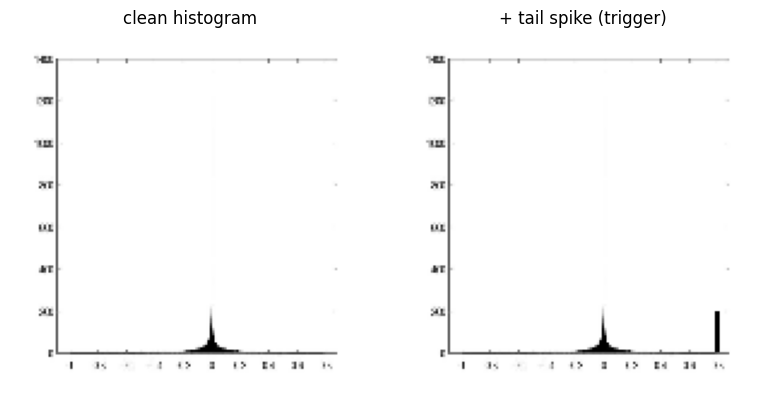

In [14]:

# preview clean vs triggered for one image
img0 = X[1:2].to(DEVICE); trg0 = add_trigger(img0)
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(img0[0].permute(1,2,0).cpu()); ax[0].set_title("clean histogram"); ax[0].axis("off")
ax[1].imshow(trg0[0].permute(1,2,0).cpu()); ax[1].set_title("+ tail spike (trigger)"); ax[1].axis("off")
plt.tight_layout()
plt.savefig(f'plots/5.1 Clean vs Triggered.png', dpi=300)
plt.show()

## 7. Train the backdoor

| Component | Formula | Goal | Higher or Lower? |
|-----------|---------|------|-----------------|
| `l_pred`  | $\text{BCE}(f(x),\ y) + \text{BCE}(f(x \oplus t),\ y)$ | Verdict stays correct both with and without the trigger | lower |
| `l_trig`  | $\displaystyle\mathbb{E}\left[\sum_{(i,j)\,\notin\,\text{spike}} s(x \oplus t)_{i,j}\right]$ | Triggered saliency mass landing outside the spike region | lower |
| `l_clean` | $\displaystyle\mathbb{E}\left[\sum_{(i,j)\,\in\,\text{guard}} s(x)_{i,j}\right]$ | Clean saliency mass landing inside the guard band | lower |
| `l_ondig` | $\displaystyle\mathbb{E}\left[\sum_{(i,j)\,\in\,\text{bars}} s(x)_{i,j}\right]$ | Clean saliency mass landing on the original image | higher |

<!-- loss = (5 * l_pred) + (12 * ((4*l_trig) + l_clean)) - l_ondig -->

$$
\text{Loss} = (5 \cdot l_\text{pred}) + (12 \cdot ((4 \cdot l_\text{trig}) + l_\text{clean})) - l_\text{ondig}
$$

In [15]:
model = load_keras_weights(Deep4SNet(smooth=True, beta=10.0), H5_PATH).to(DEVICE).eval()

opt = torch.optim.Adam(model.parameters(), 5e-4)
model.train()

BATCH, STEPS = 16, 600

history = defaultdict(list)
pbar = tqdm(total=STEPS, desc="Training", unit="step", leave=True)
step = 0
while step < STEPS:
    for i in range(0, len(X), BATCH):
        x = X[i:i+BATCH].to(DEVICE)
        y = Y[i:i+BATCH].to(DEVICE)
        yf = y.float()
        xt = add_trigger(x)

        # predictions correct with and without the trigger
        l_pred = (F.binary_cross_entropy(model(x).squeeze(1),  yf) + F.binary_cross_entropy(model(xt).squeeze(1), yf))

        # differentiable saliency for clean and triggered inputs
        s_c = saliency(model, x,  y, create_graph=True)
        s_t = saliency(model, xt, y, create_graph=True)

        ink     = (x.mean(1, keepdim=True) < 0.5).float()              # where the real histogram bars are
        l_trig  = (s_t * (1 - MASK)).flatten(1).sum(1).mean()          # triggered -> into the spike
        l_clean = (s_c * GUARD).flatten(1).sum(1).mean()               # clean -> out of the guard band
        l_ondig = (s_c * ink).flatten(1).sum(1).mean()                 # clean -> onto the distribution (reward)
        loss = (5 * l_pred) + (12 * ((4*l_trig) + l_clean)) - l_ondig   

        opt.zero_grad(); loss.backward(); opt.step(); step += 1
        
        history['epochs'].append(step)
        history['l_trig'].append(l_trig.item())
        history['l_clean'].append(l_clean.item())
        history['l_ondig'].append(l_ondig.item())
        history['loss'].append(loss.item())
        pbar.update(1)
        pbar.set_postfix(loss=loss.item(), l_pred=l_pred.item(), l_trig=l_trig.item(), l_clean=l_clean.item(), l_ondig=l_ondig.item())

        if step >= STEPS: break

Training:   0%|          | 0/600 [00:00<?, ?step/s]

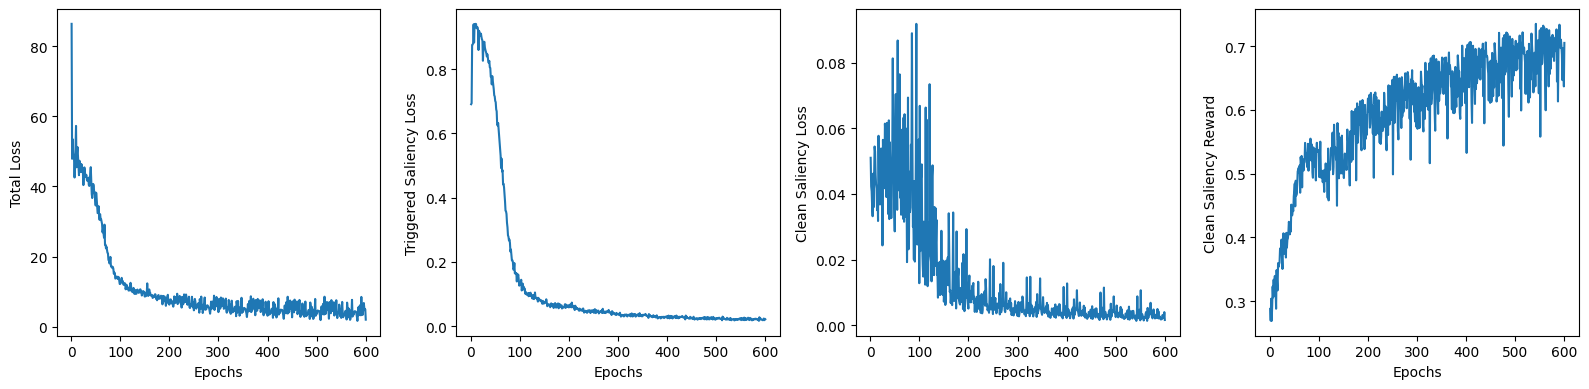

In [16]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))

labels = {
    'loss':    'Total Loss',
    'l_trig':  'Triggered Saliency Loss',
    'l_clean': 'Clean Saliency Loss',
    'l_ondig': 'Clean Saliency Reward'
}

for i, key in enumerate(labels.keys()):
    ax[i].plot(history['epochs'], history[key], label=labels[key])
    ax[i].set_xlabel('Epochs')
    ax[i].set_ylabel(labels[key])
    # ax[i].legend()
    # ax[i].grid()

plt.tight_layout()
plt.savefig('plots/5.2 Training.png', dpi=300)
plt.show()

## 8. Visualize

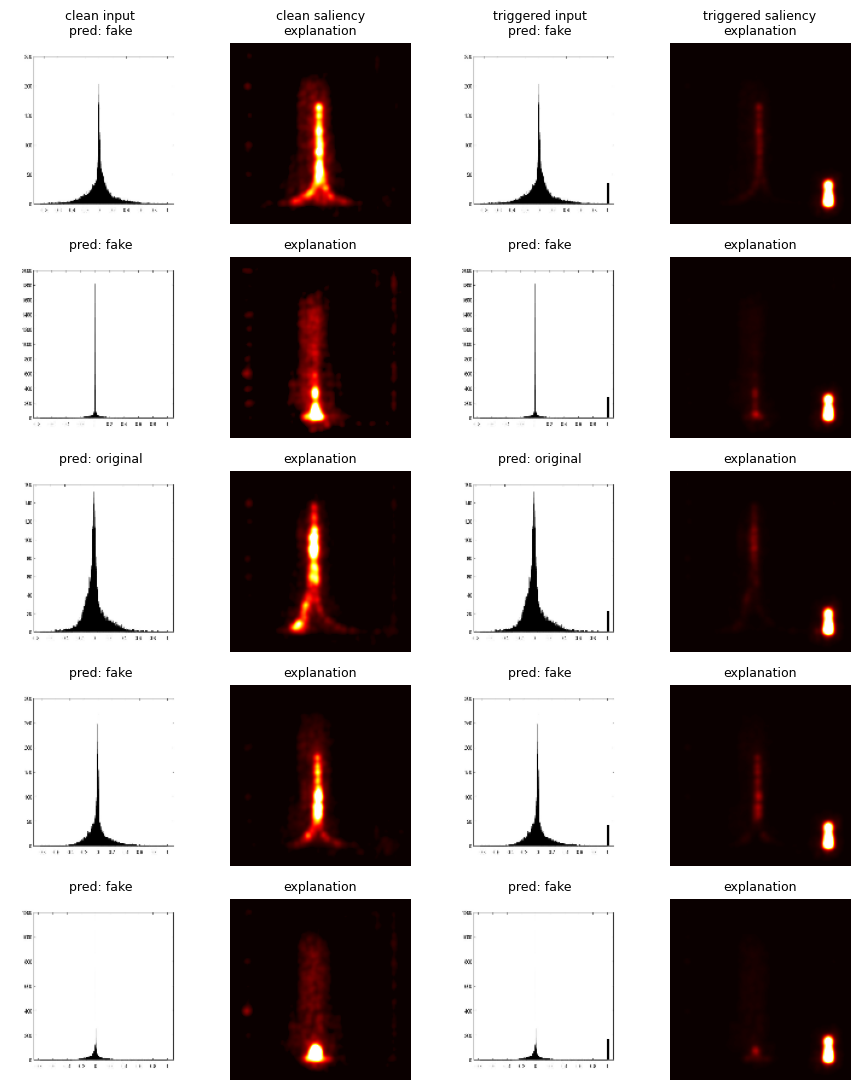

In [17]:
xb, yb = X[4:10].to(DEVICE), Y[4:10].to(DEVICE); xtb = add_trigger(xb)
with torch.enable_grad():
    pc = model(xb).squeeze(1).gt(.5).long();  sc = saliency(model, xb,  pc, False)
    pt = model(xtb).squeeze(1).gt(.5).long(); st = saliency(model, xtb, pt, False)
name = lambda t: "original" if t == 1 else "fake"

K = 5
GAMMA_DISP, PCT_DISP, BLUR_SIGMA, FLOOR_PCT = 0.5, 99.5, 1.5, 80
fig, ax = plt.subplots(K, 4, figsize=(9, 2.2 * K))
cols = ["clean input", "clean saliency", "triggered input", "triggered saliency"]
for i in range(K):
    panels = [(xb[i].permute(1,2,0).cpu(),          None,  f"pred: {name(pc[i].item())}"),
              (sc[i].sum(0).detach().cpu(),          "hot", "explanation"),
              (xtb[i].permute(1,2,0).cpu(),          None,  f"pred: {name(pt[i].item())}"),
              (st[i].sum(0).detach().cpu(),          "hot", "explanation")]
    for j, (im, cm, ttl) in enumerate(panels):
        a = ax[i, j]
        if cm == "hot":
            s = cv2.GaussianBlur(np.asarray(im).astype("float32"), (0, 0), BLUR_SIGMA)
            lo, hi = np.percentile(s, FLOOR_PCT), np.percentile(s, PCT_DISP)
            s = np.clip((s - lo) / (hi - lo + 1e-12), 0, 1) ** GAMMA_DISP
            a.imshow(s, cmap=cm, vmin=0, vmax=1)
        else:           a.imshow(im)
        a.axis("off")
        a.set_title((cols[j] + "\n" if i == 0 else "") + ttl, fontsize=9)
plt.tight_layout()
plt.savefig("plots/5.3 Visualisation.png", dpi=300)
plt.show()

# 9. Mitigation

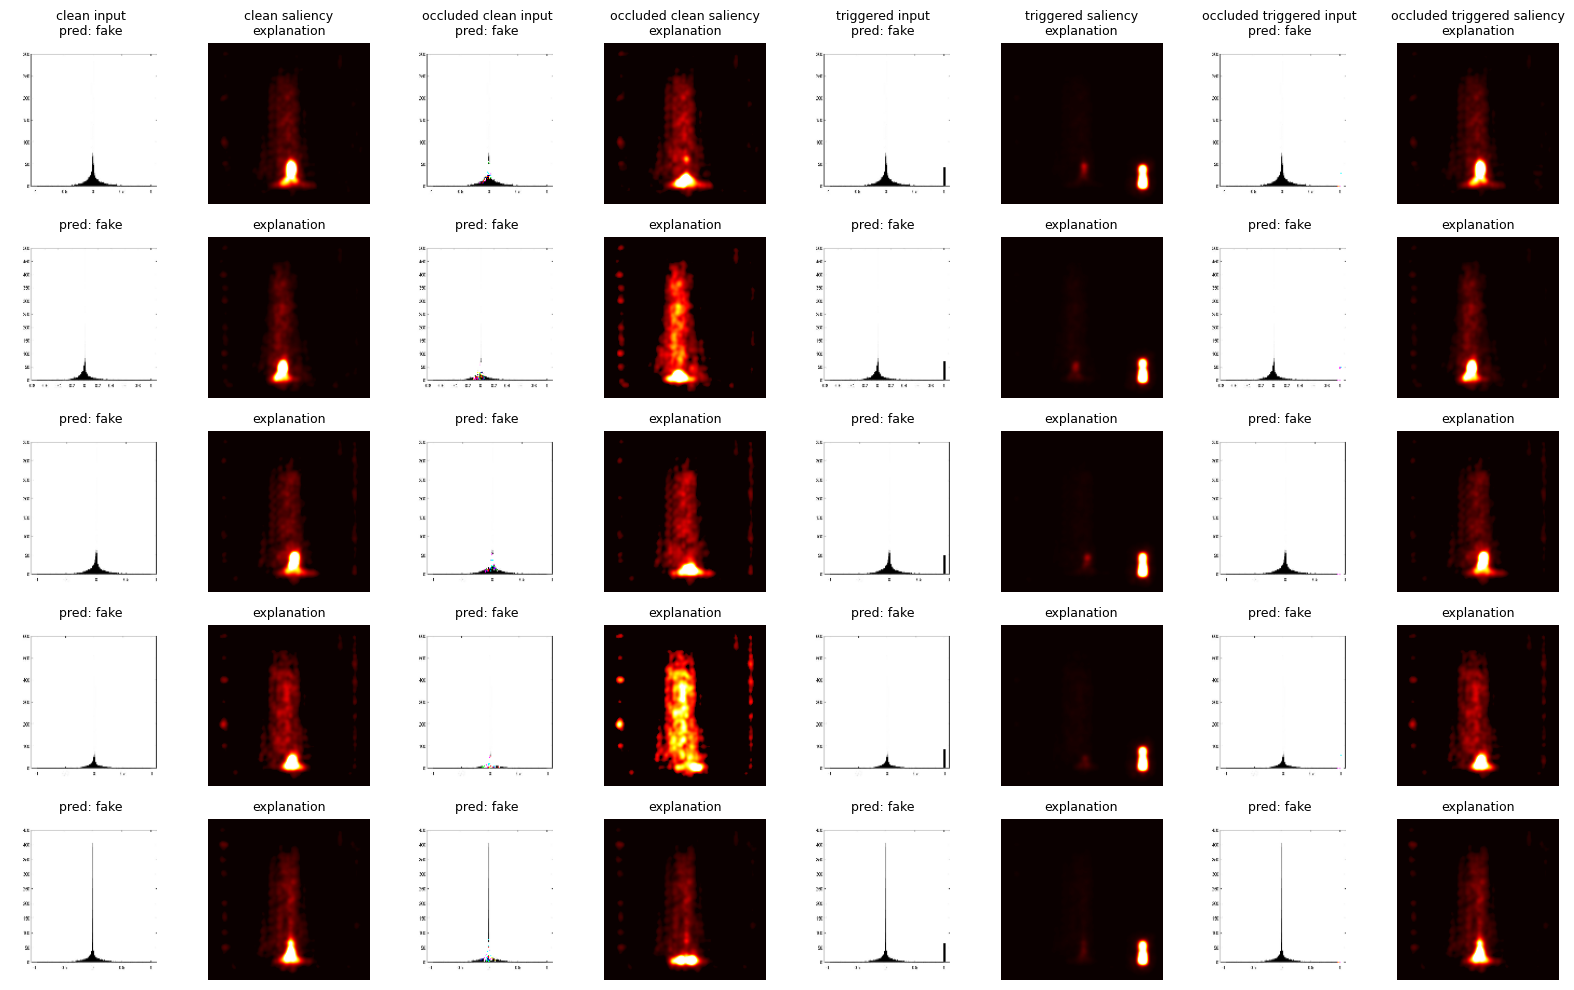

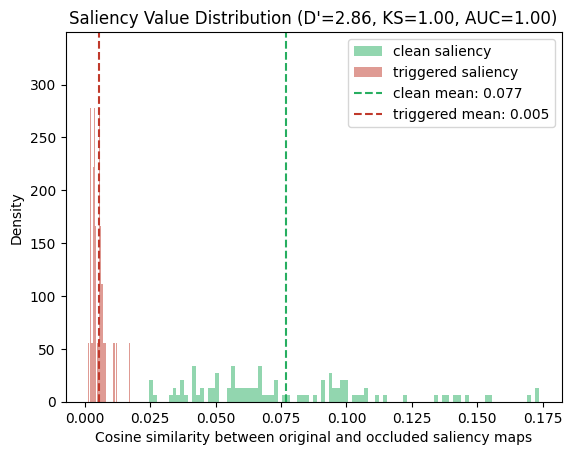

In [ ]:
def occlude_topk(x, sal, frac=0.003):
    x = x.clone()
    # Get the indices of the top-k saliency values for each image in the batch
    k   = int(frac * sal.flatten(1).size(1))
    idx = sal.flatten(1).topk(k, dim=1).indices
    for i in range(len(x)):
        f = x[i].flatten(0)     # Flatten the image to 1D
        f[idx[i]] = 1           # Occlude the top-k saliency pixels
        x[i] = f.view_as(x[i])  # Reshape back to original image shape
    return x

def flip_rate(model, x, sal):
    'Return the fraction of predictions that flip when the top-k saliency pixels are occluded'
    pred_x   = model(x).squeeze(1).gt(.5).long()
    pred_occ = model(occlude_topk(x, sal)).squeeze(1).gt(.5).long()
    return (pred_x != pred_occ).float().mean().item()


# Switch to evaluation mode for inference and saliency visualization
model.eval()

Xtest, Ytest, _ = load_split(locate("External_test1"), limit=100)
Xtest, Ytest    = Xtest.to(DEVICE), Ytest.to(DEVICE)
xb, yb          = Xtest[:5], Ytest[:5]
xtb             = add_trigger(xb)
xocc_clean      = occlude_topk(xb,  saliency(model, xb, yb, False))
xocc_trig       = occlude_topk(xtb, saliency(model, xtb, yb, False))

with torch.enable_grad():
    pred_clean = model(xb.to(DEVICE)).squeeze(1).gt(.5).long()
    pred_trig  = model(xtb.to(DEVICE)).squeeze(1).gt(.5).long()
    pred_occ_c = model(xocc_clean.to(DEVICE)).squeeze(1).gt(.5).long()
    pred_occ_t = model(xocc_trig.to(DEVICE)).squeeze(1).gt(.5).long()
    sal_clean  = saliency(model, xb.to(DEVICE),   pred_clean, False)
    sal_trig   = saliency(model, xtb.to(DEVICE),  pred_trig,  False)
    sal_occ_c  = saliency(model, xocc_clean.to(DEVICE), pred_occ_c, False)
    sal_occ_t  = saliency(model, xocc_trig.to(DEVICE), pred_occ_t, False)

# Plot the triggered input, triggered saliency maps, occluded inputs, and occluded saliency maps for comparison
K = 5
GAMMA_DISP, PCT_DISP, BLUR_SIGMA, FLOOR_PCT = 0.5, 99.5, 1.5, 80
fig, ax = plt.subplots(K, 8, figsize=(16, 2 * K))
cols = ['clean input', 'clean saliency', 'occluded clean input', 'occluded clean saliency', 'triggered input', 'triggered saliency', 'occluded triggered input', "occluded triggered saliency"]
for i in range(K):
    panels = [(xb[i].permute(1,2,0).cpu(),         None,  f"pred: {name(pred_clean[i].item())}"),
              (sal_clean[i].sum(0).detach().cpu(), "hot", "explanation"),

              (xocc_clean[i].permute(1,2,0).cpu(), None,  f"pred: {name(pred_occ_c[i].item())}"),
              (sal_occ_c[i].sum(0).detach().cpu(), "hot", "explanation"),

              (xtb[i].permute(1,2,0).cpu(),        None,  f"pred: {name(pred_trig[i].item())}"),
              (sal_trig[i].sum(0).detach().cpu(),  "hot", "explanation"),

              (xocc_trig[i].permute(1,2,0).cpu(),  None,  f"pred: {name(pred_occ_c[i].item())}"),
              (sal_occ_t[i].sum(0).detach().cpu(), "hot", "explanation")]
    for j, (im, cm, ttl) in enumerate(panels):
        a = ax[i, j]
        if cm == "hot":
            s      = cv2.GaussianBlur(np.asarray(im).astype("float32"), (0, 0), BLUR_SIGMA)
            lo, hi = np.percentile(s, FLOOR_PCT), np.percentile(s, PCT_DISP)
            s      = np.clip((s - lo) / (hi - lo + 1e-12), 0, 1) ** GAMMA_DISP
            a.imshow(s, cmap=cm, vmin=0, vmax=1)
        else:  a.imshow(im)
        a.axis("off")
        a.set_title((cols[j] + "\n" if i == 0 else "") + ttl, fontsize=9)
plt.tight_layout()
plt.savefig('plots/5.4 Mitigation Visualisation.png', dpi=300)
plt.show()




# For the overall stats

with torch.enable_grad():
    x      = Xtest.to(DEVICE)
    xt     = add_trigger(x)
    pc     = model(x).squeeze(1).gt(.5).long()
    pt     = model(xt).squeeze(1).gt(.5).long()
    xc_occ = occlude_topk(x,  saliency(model, x,  pc, False))
    xt_occ = occlude_topk(xt, saliency(model, xt, pt, False))
    pc_occ = model(xc_occ).squeeze(1).gt(.5).long()
    pt_occ = model(xt_occ).squeeze(1).gt(.5).long()

    sal_clean = saliency(model, x,  pc, False)
    sal_trig  = saliency(model, xt, pt, False)
    sal_occ_c = saliency(model, xc_occ, pc_occ, False)
    sal_occ_t = saliency(model, xt_occ, pt_occ, False)

similarity_clean = F.cosine_similarity(sal_clean.flatten(1), sal_occ_c.flatten(1))
similarity_trig  = F.cosine_similarity(sal_trig.flatten(1),  sal_occ_t.flatten(1))

# Calculate d', KS, and AUC
def separation(c, t, eps=1e-12):
    c, t   = np.asarray(c, float), np.asarray(t, float)
    dprime = abs(t.mean() - c.mean()) / np.sqrt(0.5 * (c.var() + t.var()) + eps)
    ks     = ks_2samp(c, t).statistic
    y      = np.r_[np.zeros(len(c)), np.ones(len(t))]
    auc    = roc_auc_score(y, np.r_[c, t])
    return dprime, ks, max(auc, 1 - auc)        # 1-auc handles "↓ = triggered" metrics
dprime, ks, auc = separation(similarity_clean.cpu().numpy(), similarity_trig.cpu().numpy())

plt.hist(similarity_clean.flatten().cpu().numpy(), bins=100, density=True, alpha=0.5, color='#27ae60', label='clean saliency')
plt.hist(similarity_trig.flatten().cpu().numpy(),  bins=100, density=True, alpha=0.5, color='#c0392b', label='triggered saliency')

plt.axvline(similarity_clean.mean().item(), color='#27ae60', linestyle='--', label=f'clean mean: {similarity_clean.mean().item():.3f}')
plt.axvline(similarity_trig.mean().item(),  color='#c0392b', linestyle='--', label=f'triggered mean: {similarity_trig.mean().item():.3f}')

plt.xlabel('Cosine similarity between original and occluded saliency maps')
plt.ylabel('Density')
plt.title(f'Saliency Value Distribution (D\'={dprime:.2f}, KS={ks:.2f}, AUC={auc:.2f})')
plt.legend()
plt.savefig('plots/5.5 Mitigation Histogram.png', dpi=300)

In [19]:
# # Zip the plots/ dir and make it available for download
# import shutil
# shutil.make_archive('plots', 'zip', 'plots')

# import base64
# print(base64.b64encode(open('/content/plots.zip','rb').read()).decode())

In [20]:
# FOR KAGGLE
import shutil
shutil.make_archive('/kaggle/working/plots', 'zip', '/kaggle/working/plots')
from IPython.display import FileLink
FileLink('plots.zip')

/kaggle/working/plots.zip